In [1]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
theme_set(
    theme_classic(base_size = 12)
)


Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [2]:
source("./plot_data.R")

In [3]:
final_iso_tb<- read.table('../data/2_final_iso_tb.tsv', header = T, row.names = 1, sep = '\t')

## Spearman correlation between chromain state

In [126]:
chrom_usage<- read.table("../data/supp/260313_diff_nuc_promoter_restricted_usages_table.tsv", sep = "\t", header = TRUE, row.names = 1)

In [83]:
chrom_level = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible')

In [128]:
chrom_usage<- 
    chrom_usage %>%
    mutate(
        gene_id = str_split_i(rownames(chrom_usage), ':', 1),
        chrom_state = str_split_i(rownames(chrom_usage), ':', 2)) %>% 
    mutate(chrom_state = factor(chrom_state, levels = chrom_level)) %>% 
    filter(gene_id %in% final_iso_tb$gene_id)

chrom_usage_long<- chrom_usage %>%
    pivot_longer(cols = matches("^(W|M)"), names_to = "samples", values_to = "chrom_usage") %>% 
    mutate(samples = factor(samples, levels = c("WT_rep1", "WT_rep2", "MUT_rep1", "MUT_rep2")))

In [87]:
samples<- chrom_usage_long %>% pull(samples) %>% sort() %>% unique() %>% as.character()

df_pairs <- t(combn(samples, 2)) %>% 
    as.data.frame() %>%
    rename(x = V1, y = V2)

plot_corr <- function(df, x, y) {
    r <- cor(df[[x]], df[[y]], use = "complete.obs")
    
    ggplot(df, aes_string(x, y)) +
        geom_point_rast(size = 0.01, alpha = 0.1, color = "#4d4d4d") +
        annotate("text", 
                 x = 0.05, y = 1, label = paste0("Rho = ", round(r, 2)),
                 hjust = 0, vjust = 1, size = 4) +
        theme(axis.text.x = element_text(angle = 90, hjust = 0))}

df_plot <- df_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_usage, .x, .y)))


p<- wrap_plots(df_plot$plot, ncol = 3, nrow = 3)
ggsave('../figures/Supp_spearman_correaltion_chrom_usage.pdf', p, width = 6, height = 3.5)

## read differential chromatin state table

In [133]:
diff_chrom<- read.table("../data/supp/260313_diff_nuc_promoter_restricted_diff_nuc.tsv", sep = "\t", header = TRUE)

diff_chrom<- diff_chrom %>%  
    filter(gene_id %in% final_iso_tb$gene_id) %>% 
    mutate(config = str_split_i(nucid, ':', 2), 
           labels = 'Not sig')

print('total number of events in diff usage:')

dim(diff_chrom)

print('total number of genes in diff usage:')
diff_chrom$gene_id %>% sort() %>% unique() %>% length()

# diff_chrom has same number of genes as chrom_usage

[1] "total number of events in diff usage:"


[1] 21652    15

[1] "total number of genes in diff usage:"


[1] 6009

In [138]:
delta_cutoff = 0.05
padj_cutoff = 0.05
annot_down = 6
annot_up = 6

diff_chrom[(diff_chrom$delta < -delta_cutoff) & 
         (diff_chrom$pval_adj < padj_cutoff), "labels"] =  'Down in MUT'

diff_chrom[(diff_chrom$delta > delta_cutoff) & 
         (diff_chrom$pval_adj < padj_cutoff), "labels"] = 'Up in MUT'


diff_chrom$labels<- factor(diff_chrom$labels, levels = c('Not sig', 'Down in MUT', 'Up in MUT'))
table(diff_chrom$labels)


down<- c(diff_chrom %>% filter(labels != 'Not sig') %>% arrange(delta_cutoff) %>% head(annot_down) %>% rownames())
up<- c(diff_chrom %>% filter(labels != 'Not sig') %>% arrange(delta_cutoff) %>% tail(annot_up) %>% rownames())

annot<- c(down, up)
diff_chrom[annot, 'annotation'] = diff_chrom[annot, 'gene_id']


diff_chrom$type = diff_chrom$config
diff_chrom[diff_chrom$labels == 'Not sig', 'type'] = 'Not sig'

diff_chrom<- diff_chrom %>%
    mutate(type = factor(type, levels = c('promoter-accessible', 'intragenic-accessible', 'co-accessible', 'fully-nucleosomal', 'fully-accessible',  'Not sig')))

# gene classification
diff_chrom$class= final_iso_tb[match(diff_chrom$gene_id, final_iso_tb$gene_id), "class"]
diff_chrom$class<- factor(diff_chrom$class, levels = c('low', 'medium', 'high'))
diff_chrom %>% distinct(gene_id, class) %>% count(class) %>% pull(n) %>% sum()
write.table(x = diff_chrom, file = '../data/5_chromatin_diff_chrom_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)


    Not sig Down in MUT   Up in MUT 
       8068        6014        7570 

[1] 6009

# Fraction of up and down chromatin states

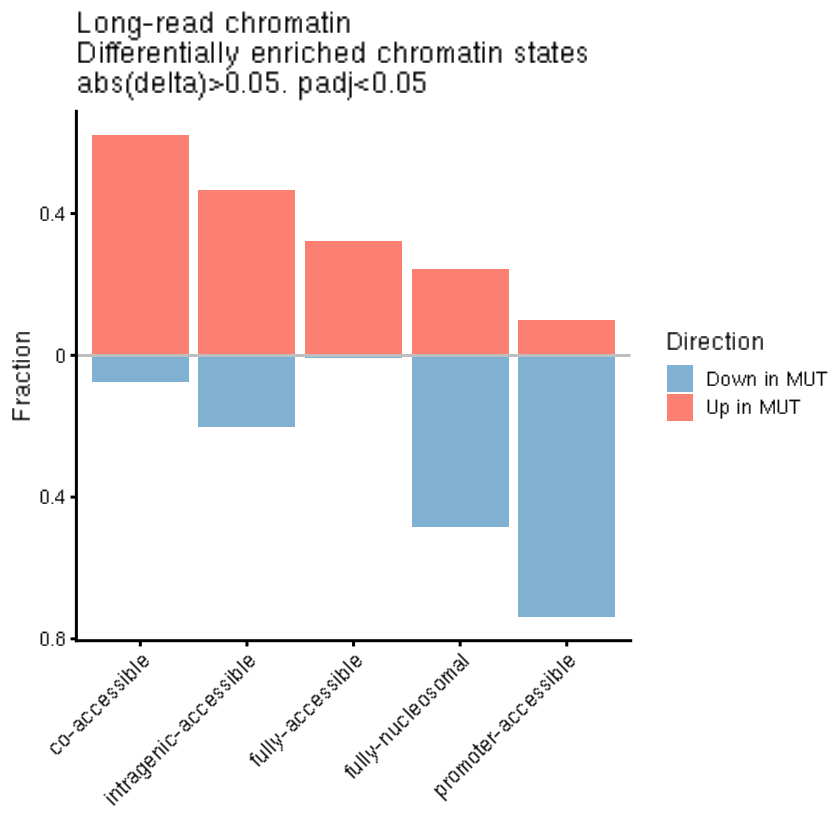

In [140]:
total_config <-  diff_chrom %>% count(config, name = "total")

df<- diff_chrom %>% 
    filter(labels != "Not sig") %>% 
    count(labels, config) %>%  
    mutate(n = ifelse(labels == "Down in MUT", -n, n)) %>% 
    left_join(total_config, by = "config") %>%
    mutate(frac = n/total)

order = df %>% arrange(-df$frac) %>% pull(config) %>% unique()

df$config<- factor(df$config, levels = order)


ggplot(df, aes(x = config, y = frac, fill = labels)) +
    geom_col() +
    scale_fill_manual(values = c("Down in MUT" = "#80b1d3", "Up in MUT" = "#fb8072")) +
    scale_y_continuous(labels = function(x) abs(x)) +
    theme_classic(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    geom_hline(yintercept = 0, color = "Gray") +
    labs(x = "", y = "Fraction", fill = "Direction",
         title = "Long-read chromatin\nDifferentially enriched chromatin states\nabs(delta)>0.05. padj<0.05")

ggsave("../figures/Supp_chromatin_percentage_of_DU_config.pdf",,  width = 5, height = 4)

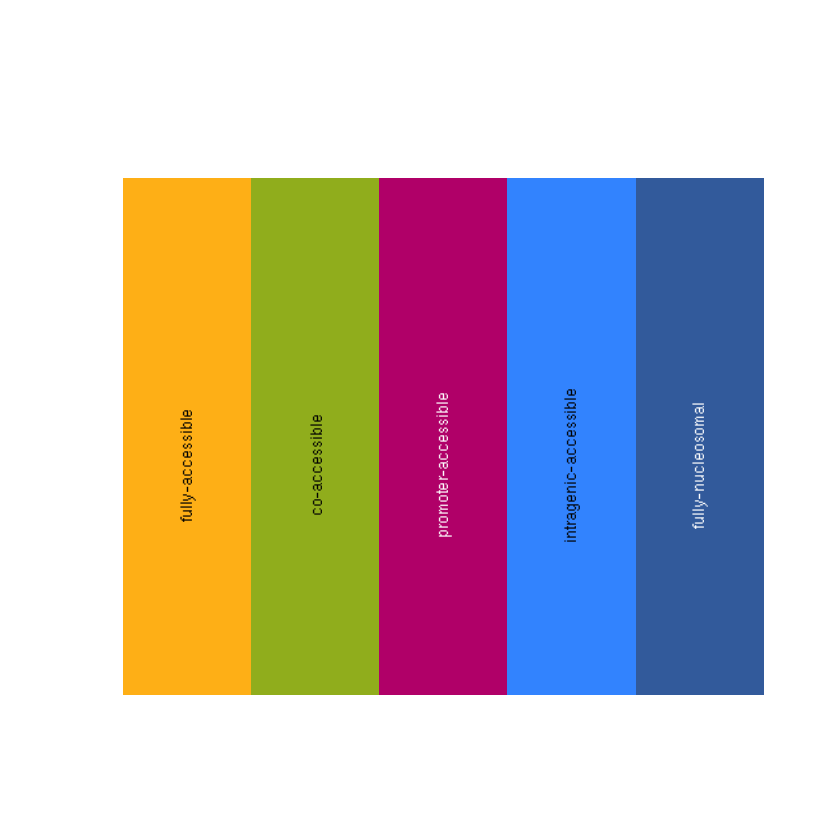

In [141]:
mcolors <- polychrome()[c(7, 10, 8, 6, 15)]
names(mcolors) <- c('fully-accessible', 'co-accessible', 'promoter-accessible', 'intragenic-accessible', 'fully-nucleosomal')
pal.bands(mcolors)
mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

## Distrubution of up and down regulated chromatin in gene expression group

In [142]:
diff_chrom = read.table(file = '../data/5_chromatin_diff_chrom_results.tsv', sep = '\t', header = T, row.names = 1)

In [143]:
diff_chrom$config %>% table()

.
        co-accessible      fully-accessible     fully-nucleosomal 
                 5816                  5988                  3237 
intragenic-accessible   promoter-accessible 
                 1655                  4956 

In [144]:
df1<- diff_chrom %>%
    count(class, labels, name = 'total_per_label') %>% left_join(count(diff_chrom, class, name = 'total'))

df2<- diff_chrom %>%
    count(labels, config, class) %>% 
    left_join(df1, by = join_by(labels, class)) %>% 
    mutate(p_per_label = n/total_per_label, p = n/total)

chrom_new_level <- df2 %>%
    filter(labels != "Not sig", class == "low") %>% 
    select(config, labels, p) %>% 
    pivot_wider(names_from = labels, values_from = p) %>% 
    mutate(delta = `Up in MUT` - `Down in MUT`) %>% arrange(-delta) %>% 
    pull(config)


write.table(df2 %>% select(class, config, labels, n, total_per_label, total, p_per_label, p),
          '../data/5_chromatin_diff_chrom_fraction_by_expr.tsv', quote = F, sep = '\t', col.names = T, row.names = F)

Joining with `by = join_by(class)`


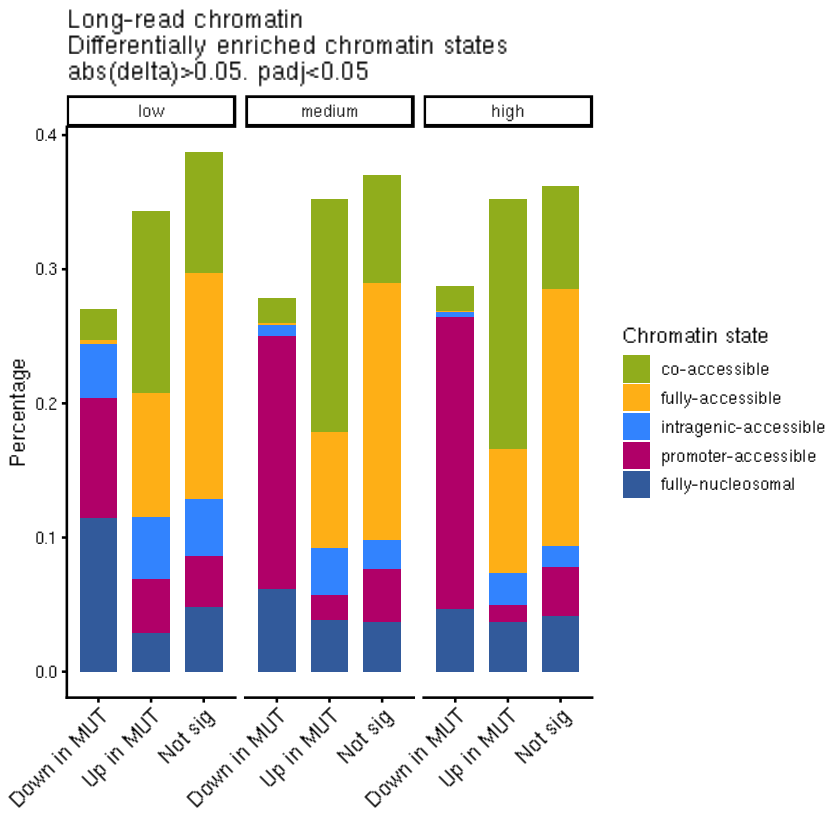

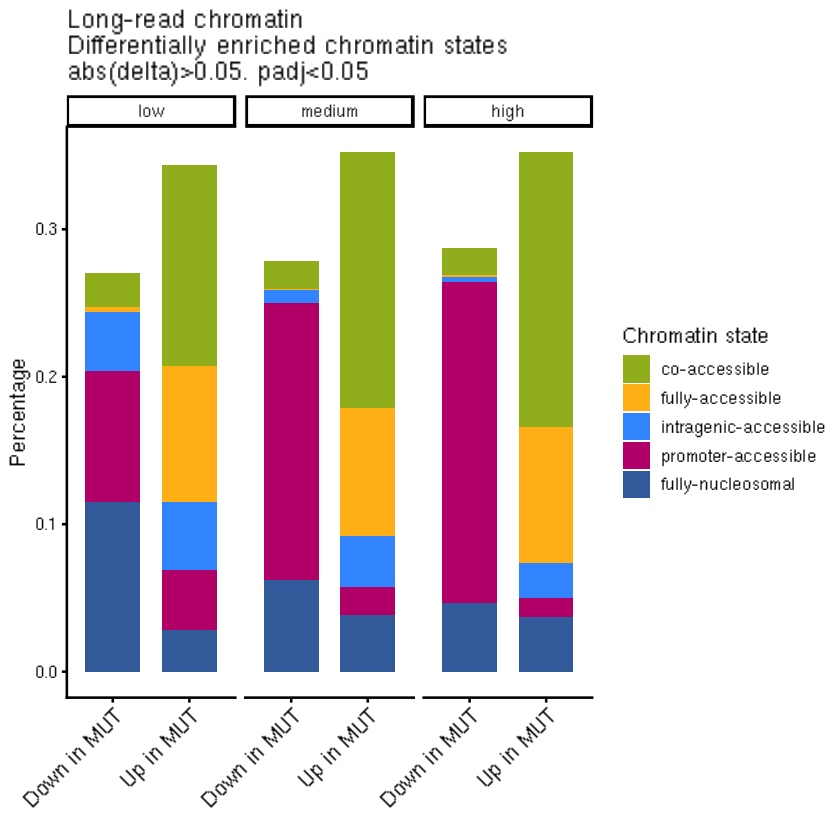

In [145]:
p1<- df2 %>%
    mutate(config = factor(config, levels = chrom_new_level),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig")),
           class = factor(class, levels = c("low", "medium", "high"))) %>% 
    ggplot(aes(x = labels, y = p, fill = config)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    labs(x = "", y = "Percentage", 
         title = "Long-read chromatin\nDifferentially enriched chromatin states\nabs(delta)>0.05. padj<0.05", fill = "Chromatin state") +
    facet_wrap(vars(class), ncol = 3)
p1
ggsave("../figures/Supp_chromatin_percentage_of_config_by_expr_with_sig.pdf", p1, width = 6, height = 4)

p2<- df2 %>%
    mutate(config = factor(config, levels = chrom_new_level),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig")),
           class = factor(class, levels = c("low", "medium", "high"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = config)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    labs(x = "", y = "Percentage", title = "Long-read chromatin\nDifferentially enriched chromatin states\nabs(delta)>0.05. padj<0.05", fill = "Chromatin state") +
    facet_wrap(vars(class), ncol = 3) 
p2
ggsave("../figures/Supp_chromatin_percentage_of_config_by_expr.pdf", p2, width = 6, height = 4)

## find genes with shifting chromatin states

In [146]:
chrom_delta<- chrom_usage %>%
        mutate(delta = (rowMeans(select(., starts_with("MUT"))) - rowMeans(select(., starts_with("WT"))))) %>% 
        select(gene_id, chrom_state, delta) %>% 
        complete(gene_id, chrom_state = chrom_level, fill = list(delta = 0)) %>% 
        mutate(chrom_state = factor(chrom_state, levels = chrom_level)) %>% 
        arrange(gene_id, chrom_state) %>% 
        pivot_wider(names_from = chrom_state, values_from = delta)

chrom_delta$class <- final_iso_tb[match(chrom_delta$gene_id, final_iso_tb$gene_id), "class"]

write.table(x = chrom_delta, file = "../data/5_chromatin_delta_usage_per_gene", sep = "\t", col.names = T, row.names = F, quote = F)

pdf 
  2

pdf 
  2

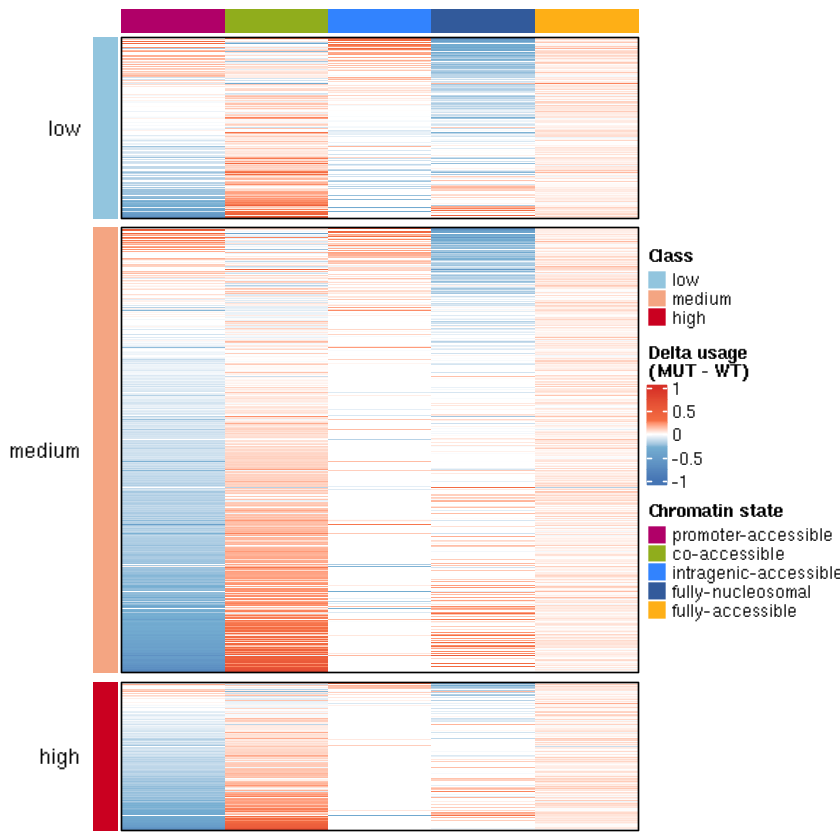

In [147]:
mcolors <- polychrome()[c(7, 10, 8, 6, 15)]
names(mcolors) <- c("fully-accessible", "co-accessible", "promoter-accessible",
                     "intragenic-accessible", "fully-nucleosomal")

class_colors <- c(low = "#92c5de", medium = "#f4a582", high = "#ca0020")

col_order <- c("promoter-accessible", "co-accessible","intragenic-accessible",
               "fully-nucleosomal", "fully-accessible")

mat_df <- chrom_delta %>%
  mutate(class = factor(class, levels = c("low", "medium", "high"))) %>%
  arrange(class)

mat <- mat_df %>%
  select(all_of(col_order)) %>%
  as.matrix()

rownames(mat) <- mat_df$gene_id


row_split <- factor(mat_df$class, levels = c("low", "medium", "high"))

dir_col <- colorRamp2(
  c(-1, -0.3, 0, 0.3, 1),
  c("#4575b4", "#74add1", "white", "#f46d43", "#d73027")
)

chrom_types <- factor(colnames(mat), levels = col_order)

row_ha <- rowAnnotation(
  Class = mat_df$class,
  col   = list(Class = class_colors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

col_ha <- HeatmapAnnotation(
  Chromatin = chrom_types,
  col       = list(Chromatin = mcolors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

row_order_idx <- mat_df %>%
  mutate(
    row_idx = row_number(),
    pc1 = prcomp(mat, center = TRUE, scale. = TRUE)$x[, 1]
  ) %>%
  arrange(class, pc1) %>%
  pull(row_idx)
mat    <- mat[row_order_idx, ]
mat_df <- mat_df[row_order_idx, ]

ht <- Heatmap(
  mat,
  name                = "delta",
  col                 = dir_col,
  row_split           = row_split,
  cluster_rows        = FALSE,
  cluster_row_slices  = FALSE,
  cluster_columns     = FALSE,
  show_row_names      = FALSE,
  show_column_names   = FALSE,
  show_heatmap_legend = FALSE,
  row_gap             = unit(2, "mm"),
  row_title_rot       = 0,
  row_title_gp        = gpar(fontsize = 12),
  column_title_rot    = 0,
  column_title_gp     = gpar(fontsize = 12),
  border              = TRUE,
  rect_gp             = gpar(col = "white", lwd = 0),
  left_annotation     = row_ha,
  top_annotation      = col_ha
)

lgd_class <- Legend(
  title     = "Class",
  labels    = names(class_colors),
  legend_gp = gpar(fill = class_colors)
)

lgd_delta <- Legend(
  title     = "Delta usage\n(MUT - WT)",
  col_fun   = dir_col,
  at        = c(-1, -0.5, 0, 0.5, 1),
  direction = "vertical"
)

lgd_chrom <- Legend(
  title     = "Chromatin state",
  labels    = col_order,
  legend_gp = gpar(fill = mcolors[col_order])
)

pdf("../figures/Supp_chromatin_usage_delta_heatmap.pdf", width = 5, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_class, lgd_delta, lgd_chrom),
     heatmap_legend_side = "right")
dev.off()

png("../figures/Supp_chromatin_usage_delta_heatmap.png", res = 300, units = "in", width = 5, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_class, lgd_delta, lgd_chrom),
     heatmap_legend_side = "right")
dev.off()

draw(ht,
     annotation_legend_list = list(lgd_class, lgd_delta, lgd_chrom),
     heatmap_legend_side = "right")


## Spearman correlation between delta chromatin state usage

In [148]:
plot_corr <- function(df, x, y, expr){

    test <- cor.test(df[[x]], df[[y]], use = "complete.obs", method = "spearman", exact = FALSE)
    r <- test$estimate
    p <- test$p.value
        
    mcol <- rev(c("#ca0020", "#f4a582", "#92c5de"))
    names(mcol) <- c("low", "medium", "high")

    df_tmp<- data.frame(X = df[[x]], Y = df[[y]])    
    
    p<- ggplot(df_tmp, aes(x = X, y = Y)) +
        geom_vline(xintercept = 0.0, color = 'black', linetype = "longdash") +
        geom_hline(yintercept = 0.0, color = 'black', linetype = "longdash") +
        geom_point(size = 0.1, alpha = 0.6, color = unname(mcol[expr])) +
        annotate("text", 
                 x = -0.9, y = 1, label = paste0("Rho = ", round(r, 2), "\np = ", formatC(p, format = "e", digits = 2)),
                 hjust = 0, vjust = 1, size = 3) +
        theme_classic(base_size = 12) + 
        labs(x = paste0("Delta\n", str_replace(x, '^(.*?)-(.*?)-', '\\1-\\2\n')), 
             y = paste0("Delta\n ", str_replace(y, '^(.*?)-(.*?)-', '\\1-\\2\n'))) +
        theme(axis.text.y = element_text(angle = 0, vjust = 0.5, hjust = 1)) +
        xlim(-1, 1) +
        ylim(-1, 1)
    
    return(p)
}

In [149]:
expr = 'low'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)

### this is for ordering chromatin state and based on low expression ###
df_c<- cor(chrom_delta_c, method = 'spearman') %>% as.data.frame() %>% 
    mutate(chrom2 = chrom_level) %>% 
    pivot_longer(cols = !chrom2, names_to = 'chrom', values_to = 'cor')

chrom_pairs <- t(combn(chrom_level, 2)) %>%
    as.data.frame() %>%
    rename(x = V1, y = V2)

chrom_pairs<- inner_join(chrom_pairs, df_c, by = c("x" = "chrom2", "y" = "chrom")) %>% arrange(cor)
################################################

df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p1<- wrap_plots(df_plot$plot, ncol = 1)


expr = 'medium'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)
df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p2<- wrap_plots(df_plot$plot, ncol = 1)

expr = 'high'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)
df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p3<- wrap_plots(df_plot$plot, ncol = 1)

p<- wrap_plots(p1, p2, p3, ncol = 3)

ggsave(paste0("../figures/Supp_spearman_cor_delta_chrom_", "cor_larger_all", ".pdf"), p, width = 6, height = 10)

In [150]:
expr = 'low'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)

### this is for ordering chromatin state and based on low expression ###
df_c<- cor(chrom_delta_c, method = 'spearman') %>% as.data.frame() %>% 
    mutate(chrom2 = chrom_level) %>% 
    pivot_longer(cols = !chrom2, names_to = 'chrom', values_to = 'cor')

chrom_pairs <- t(combn(chrom_level, 2)) %>%
    as.data.frame() %>%
    rename(x = V1, y = V2)

chrom_pairs<- inner_join(chrom_pairs, df_c, by = c("x" = "chrom2", "y" = "chrom")) %>% arrange(cor) %>% filter(abs(cor)> 0.1)
################################################

df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p1<- wrap_plots(df_plot$plot, ncol = 1)


expr = 'medium'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)
df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p2<- wrap_plots(df_plot$plot, ncol = 1)

expr = 'high'
chrom_delta_c<- chrom_delta %>% filter(gene_id %in% c(final_iso_tb %>% filter(class == expr) %>% pull(gene_id))) %>% select(chrom_level)
df_plot <- chrom_pairs %>%
    mutate(plot = map2(x, y, ~plot_corr(chrom_delta_c, .x, .y, expr)))
p3<- wrap_plots(df_plot$plot, ncol = 1)

p<- wrap_plots(p1, p2, p3, ncol = 3)

ggsave(paste0("../figures/Supp_spearman_cor_delta_chrom_", "cor_larger_0.1", ".pdf"), p, width = 8, height = 8)